### Import packages, define paths and load data

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
PROJECT_ROOT = Path("/Users/tildeidunsloth/Desktop/Thesis")
DATA_DIR = PROJECT_ROOT / "data/associational_gender_bias"

In [4]:
gender_bias_df_literary_fiction = pd.read_csv(DATA_DIR / "literary_fiction_gender_bias_averaged_seeds.csv")
gender_bias_df_romance = pd.read_csv(DATA_DIR / "romance_gender_bias_averaged_seeds.csv")
gender_bias_df_sci_fi = pd.read_csv(DATA_DIR / "sci_fi_gender_bias_averaged_seeds.csv")

# add a column for genre
gender_bias_df_literary_fiction["genre"] = "Literary Fiction"
gender_bias_df_romance["genre"] = "Romance"
gender_bias_df_sci_fi["genre"] = "Sci-Fi"

# merge the three dataframes into one
gender_bias_df = pd.concat([gender_bias_df_literary_fiction, gender_bias_df_romance, gender_bias_df_sci_fi], ignore_index=True)

In [5]:
gender_bias_df_literary_fiction_no_names = pd.read_csv(DATA_DIR / "literary_fiction_no_names_gender_bias_averaged_seeds.csv")
gender_bias_df_romance_no_names = pd.read_csv(DATA_DIR / "romance_no_names_gender_bias_averaged_seeds.csv")
gender_bias_df_sci_fi_no_names = pd.read_csv(DATA_DIR / "sci_fi_no_names_gender_bias_averaged_seeds.csv")

# add a column for genre
gender_bias_df_literary_fiction_no_names["genre"] = "Literary Fiction"
gender_bias_df_romance_no_names["genre"] = "Romance"
gender_bias_df_sci_fi_no_names["genre"] = "Sci-Fi"

# merge the three dataframes into one
gender_bias_df_no_names = pd.concat([gender_bias_df_literary_fiction_no_names, gender_bias_df_romance_no_names, gender_bias_df_sci_fi_no_names], ignore_index=True)

In [6]:
# rename dimensions
gender_bias_df["dimension"] = gender_bias_df["dimension"].replace({
    "high_warmth": "High Warmth",
    "high_competence": "High Competence",
    "low_competence": "Low Competence",
    "low_warmth": "Low Warmth"})

### Violin plot

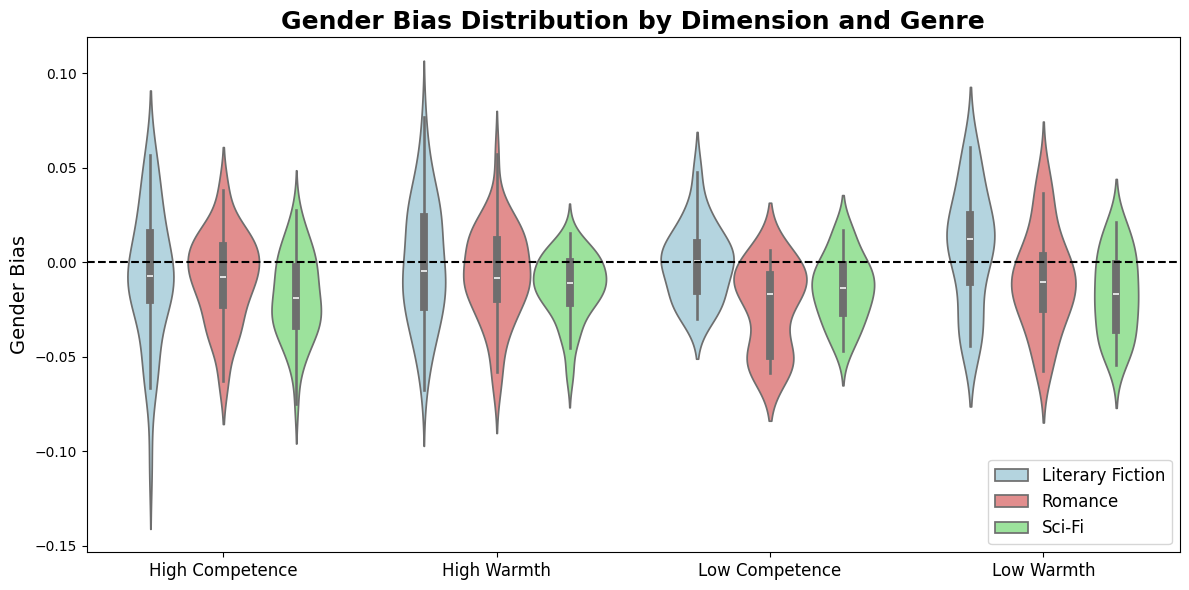

In [7]:
genre_colors = {
    "Literary Fiction": "lightblue", 
    "Romance": "lightcoral",          
    "Sci-Fi": "lightgreen"             
}

plt.figure(figsize=(12, 6))
sns.violinplot(x="dimension", y="gender_bias", hue="genre", data=gender_bias_df, 
               palette=genre_colors, split=False)
plt.title("Gender Bias Distribution by Dimension and Genre", fontsize=18, fontweight="bold")
plt.xlabel(None)
plt.xticks(fontsize=12, rotation=0)
plt.ylabel("Gender Bias", fontsize=14)
plt.axhline(0, color="black", linestyle="--")
plt.legend(fontsize=12, loc="lower right")
plt.tight_layout()
plt.show()

In [12]:
# which word is the most biased in each genre and dimension?
most_biased = gender_bias_df.groupby(["genre", "dimension"]).apply(lambda x: x.loc[x["gender_bias"].idxmin()])
print(most_biased[["genre", "dimension", "word", "gender_bias"]])

                                             genre        dimension  \
genre            dimension                                            
Literary Fiction High Competence  Literary Fiction  High Competence   
                 High Warmth      Literary Fiction      High Warmth   
                 Low Competence   Literary Fiction   Low Competence   
                 Low Warmth       Literary Fiction       Low Warmth   
Romance          High Competence           Romance  High Competence   
                 High Warmth               Romance      High Warmth   
                 Low Competence            Romance   Low Competence   
                 Low Warmth                Romance       Low Warmth   
Sci-Fi           High Competence            Sci-Fi  High Competence   
                 High Warmth                Sci-Fi      High Warmth   
                 Low Competence             Sci-Fi   Low Competence   
                 Low Warmth                 Sci-Fi       Low Warmth   

     

/var/folders/wv/k1c_2q2x52q536wp2_p2kdpm0000gn/T/ipykernel_4876/1642387903.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  most_biased = gender_bias_df.groupby(["genre", "dimension"]).apply(lambda x: x.loc[x["gender_bias"].idxmin()])


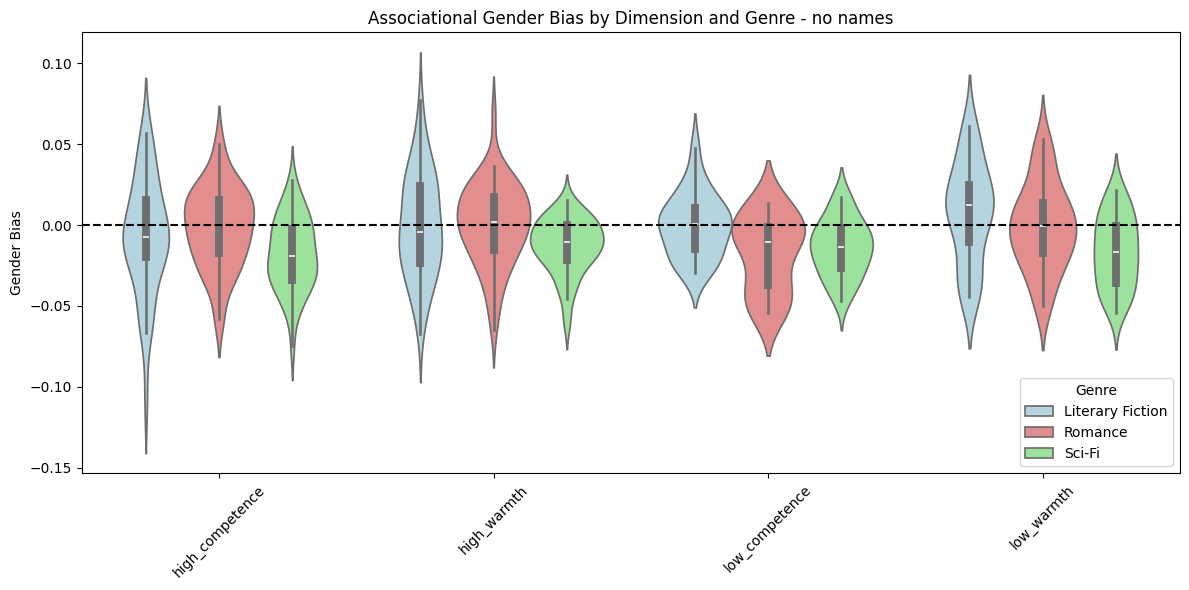

In [19]:
plt.figure(figsize=(12, 6))
sns.violinplot(x="dimension", y="gender_bias", hue="genre", data=gender_bias_df_no_names, 
               palette=genre_colors, split=False)
plt.title("Associational Gender Bias by Dimension and Genre - no names")
plt.xlabel(None)
plt.ylabel("Gender Bias")
plt.axhline(0, color="black", linestyle="--")
plt.xticks(rotation=45)
plt.legend(title="Genre")
plt.tight_layout()
plt.show()

### Point Plot

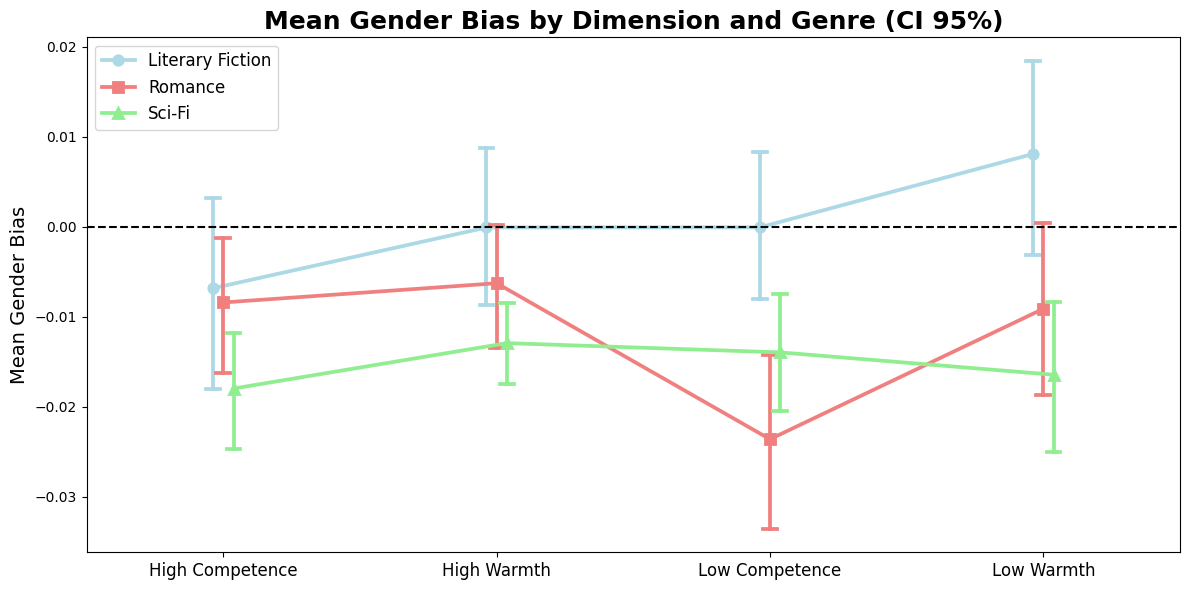

In [20]:
plt.figure(figsize=(12, 6))
sns.pointplot(
    x="dimension", 
    y="gender_bias", 
    hue="genre",
    data=gender_bias_df,
    palette=genre_colors,
    markers=["o", "s", "^"],
    linestyles="-",
    dodge=True,  # slightly separates points to avoid overlap
    capsize=0.05,  # adds caps to error bars
    errorbar="ci"  # 95% confidence interval
)
plt.axhline(0, color="black", linestyle="--")
plt.title("Mean Gender Bias by Dimension and Genre (CI 95%)", fontsize=18, fontweight="bold")
plt.xlabel(None)
plt.ylabel("Mean Gender Bias", fontsize=14)
plt.legend(loc="upper left", fontsize=12)
plt.xticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.show()

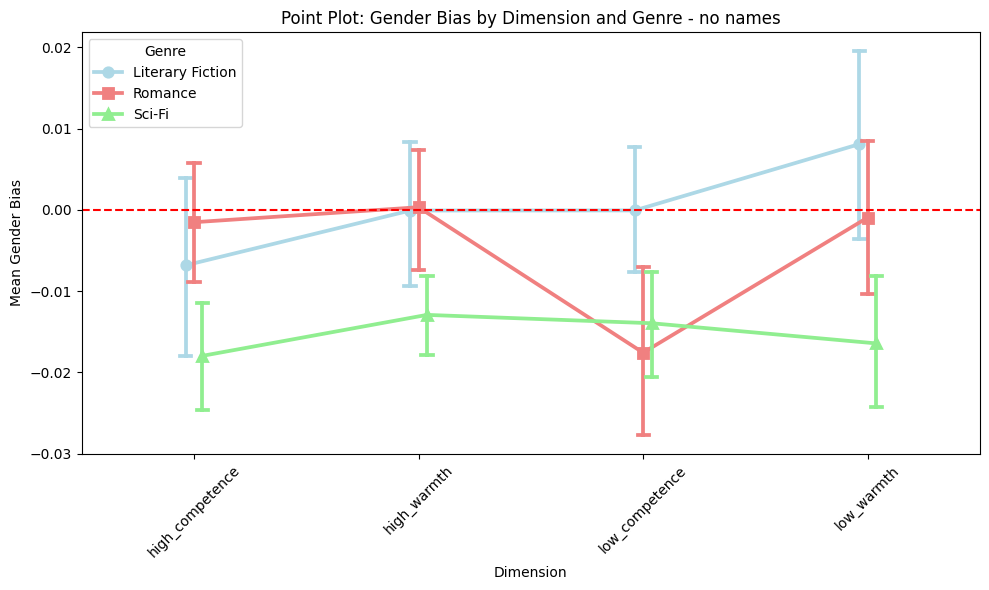

In [21]:
plt.figure(figsize=(10, 6))
sns.pointplot(
    x="dimension", 
    y="gender_bias", 
    hue="genre",
    data=gender_bias_df_no_names,
    palette=genre_colors,
    markers=["o", "s", "^"],
    linestyles="-",
    dodge=True,  # slightly separates points to avoid overlap
    capsize=0.05,  # adds caps to error bars
    errorbar="ci"  # 95% confidence interval
)
plt.axhline(0, color="red", linestyle="--")
plt.title("Point Plot: Gender Bias by Dimension and Genre - no names")
plt.xlabel("Dimension")
plt.ylabel("Mean Gender Bias")
plt.legend(title="Genre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Bar plot

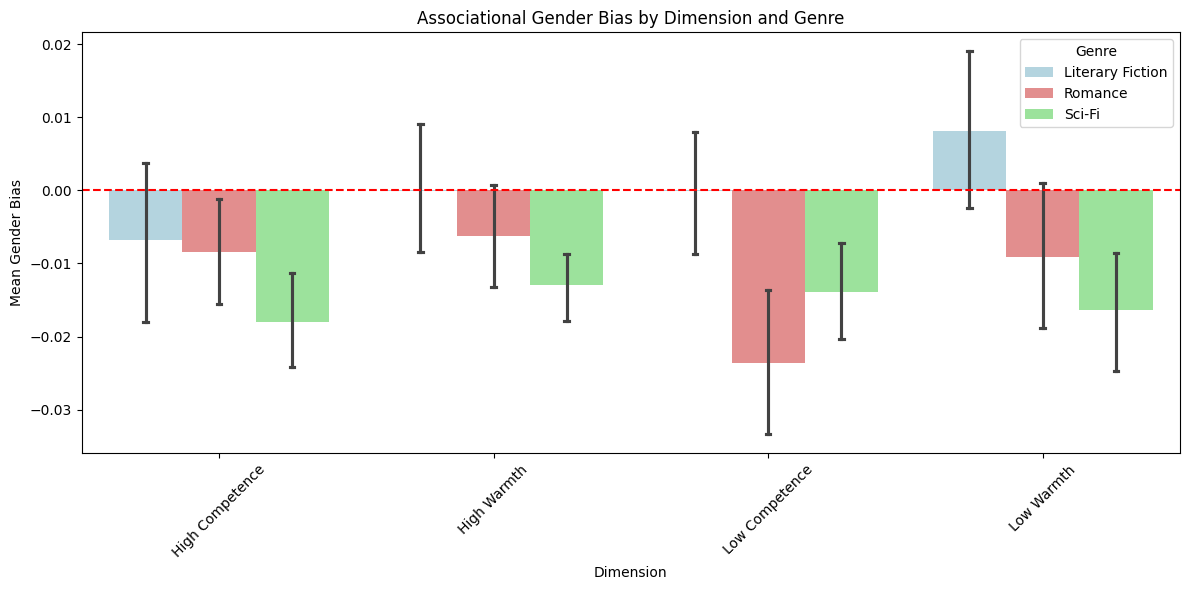

In [22]:
plt.figure(figsize=(12, 6))
sns.barplot(
    x="dimension",
    y="gender_bias",
    hue="genre",
    data=gender_bias_df,
    palette=genre_colors,
    capsize=0.05,  # adds caps to error bars
    errorbar="ci"  # 95% confidence interval
)
plt.axhline(0, color="red", linestyle="--")
plt.title("Associational Gender Bias by Dimension and Genre")
plt.xlabel("Dimension")
plt.ylabel("Mean Gender Bias")
plt.legend(title="Genre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

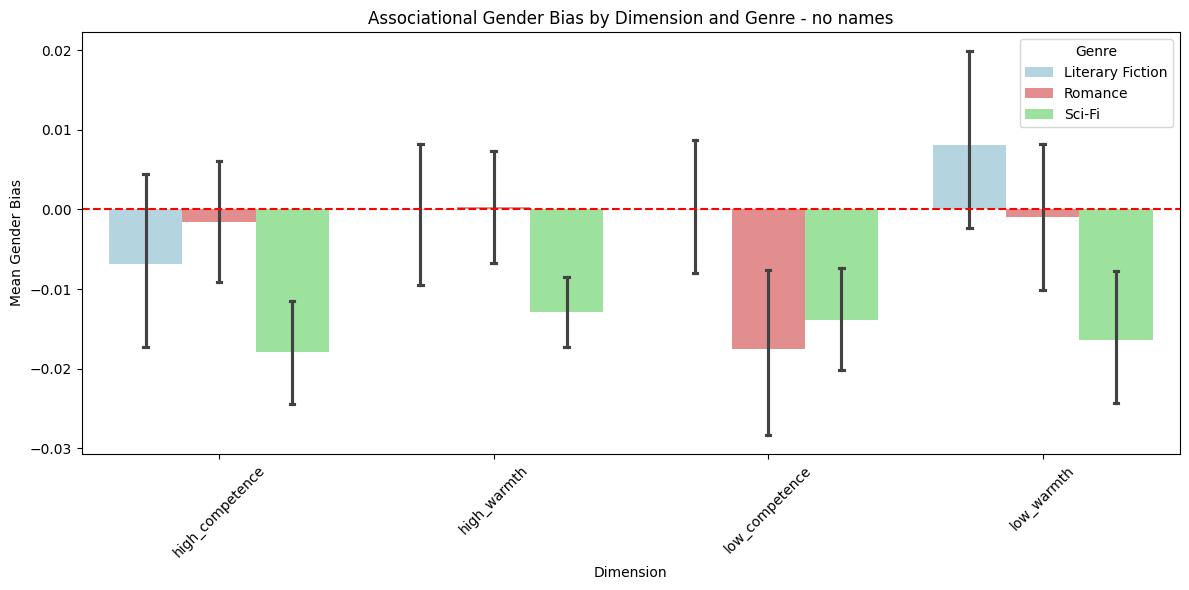

In [23]:
plt.figure(figsize=(12, 6))
sns.barplot(
    x="dimension",
    y="gender_bias",
    hue="genre",
    data=gender_bias_df_no_names,
    palette=genre_colors,
    capsize=0.05,  # adds caps to error bars
    errorbar="ci"  # 95% confidence interval
)
plt.axhline(0, color="red", linestyle="--")
plt.title("Associational Gender Bias by Dimension and Genre - no names")
plt.xlabel("Dimension")
plt.ylabel("Mean Gender Bias")
plt.legend(title="Genre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Heatmap

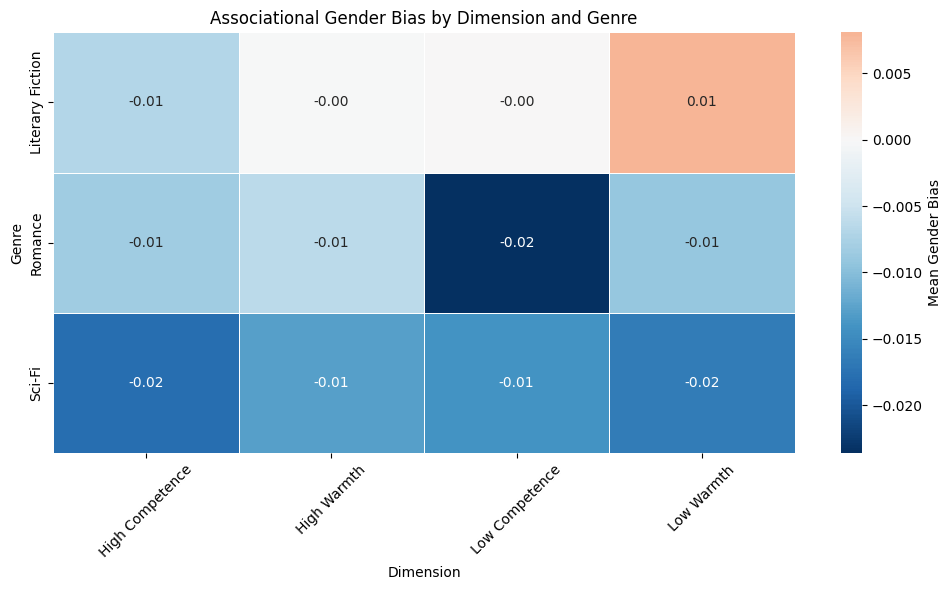

In [24]:
# create a pivot table of mean gender bias
heatmap_data = gender_bias_df.groupby(["genre", "dimension"])["gender_bias"].mean().unstack()

plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_data,
    cmap="RdBu_r",      # diverging colormap: red = male bias, blue = female bias
    center=0,           # centers the colormap at 0
    annot=True,         # shows values in each cell
    fmt=".2f",          # format to 2 decimal places
    linewidths=0.5,     # adds grid lines between cells
    cbar_kws={"label": "Mean Gender Bias"}
)
plt.title("Associational Gender Bias by Dimension and Genre")
plt.xlabel("Dimension")
plt.ylabel("Genre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

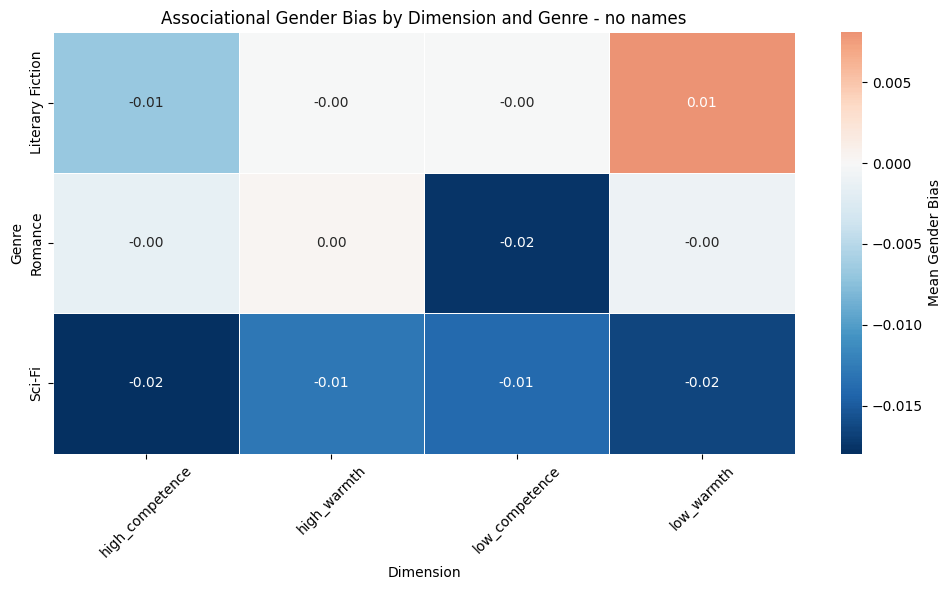

In [25]:
# create a pivot table of mean gender bias
heatmap_data_no_names = gender_bias_df_no_names.groupby(["genre", "dimension"])["gender_bias"].mean().unstack()

plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_data_no_names,
    cmap="RdBu_r",      # diverging colormap: red = male bias, blue = female bias
    center=0,           # centers the colormap at 0
    annot=True,         # shows values in each cell
    fmt=".2f",          # format to 2 decimal places
    linewidths=0.5,     # adds grid lines between cells
    cbar_kws={"label": "Mean Gender Bias"}
)
plt.title("Associational Gender Bias by Dimension and Genre - no names")
plt.xlabel("Dimension")
plt.ylabel("Genre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Horizontal bar plot

In [26]:
def plot_gender_bias_words(df, genre_name):
    """
    Plots a 2x2 grid of horizontal bar plots for each dimension in the dataframe.

    Parameters:
    - df: pd.DataFrame with columns ["dimension", "word", "gender_bias"]
    - genre_name: str, name of the genre for the main title
    """
    dimensions = ["low_warmth", "low_competence", "high_warmth", "high_competence"]
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 18))
    axes = axes.flatten()  # flatten 2x2 array for easy indexing
    
    for i, dim in enumerate(dimensions):
        dim_df = df[df["dimension"] == dim]
        word_bias = dim_df.groupby("word")["gender_bias"].mean().sort_values()
        
        colors = ["lightblue" if x > 0 else "red" for x in word_bias.values]
        word_bias.plot(kind="barh", color=colors, ax=axes[i])
        
        # Remove y-axis tick labels
        axes[i].set_yticks([])
        
        # Add word labels at the end of each bar
        for j, (word, value) in enumerate(word_bias.items()):
            if value > 0:
                axes[i].text(value + 0.001, j, word, va="center", ha="left", fontsize=12)
            else:
                axes[i].text(value - 0.001, j, word, va="center", ha="right", fontsize=12)
        
        axes[i].axvline(0, color="black", linestyle="--")
        axes[i].set_title(f"{dim.replace('_', ' ').title()} Dimension", fontsize=18, fontweight="bold")
        axes[i].set_xlabel("")
        axes[i].set_ylabel("")
        axes[i].set_xlim(-0.1, 0.1)
    
    fig.suptitle(f"Gender Bias for Individual Words in {genre_name}", fontsize=28, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.98])  # leave space for suptitle
    plt.show()

##### Literary Fiction

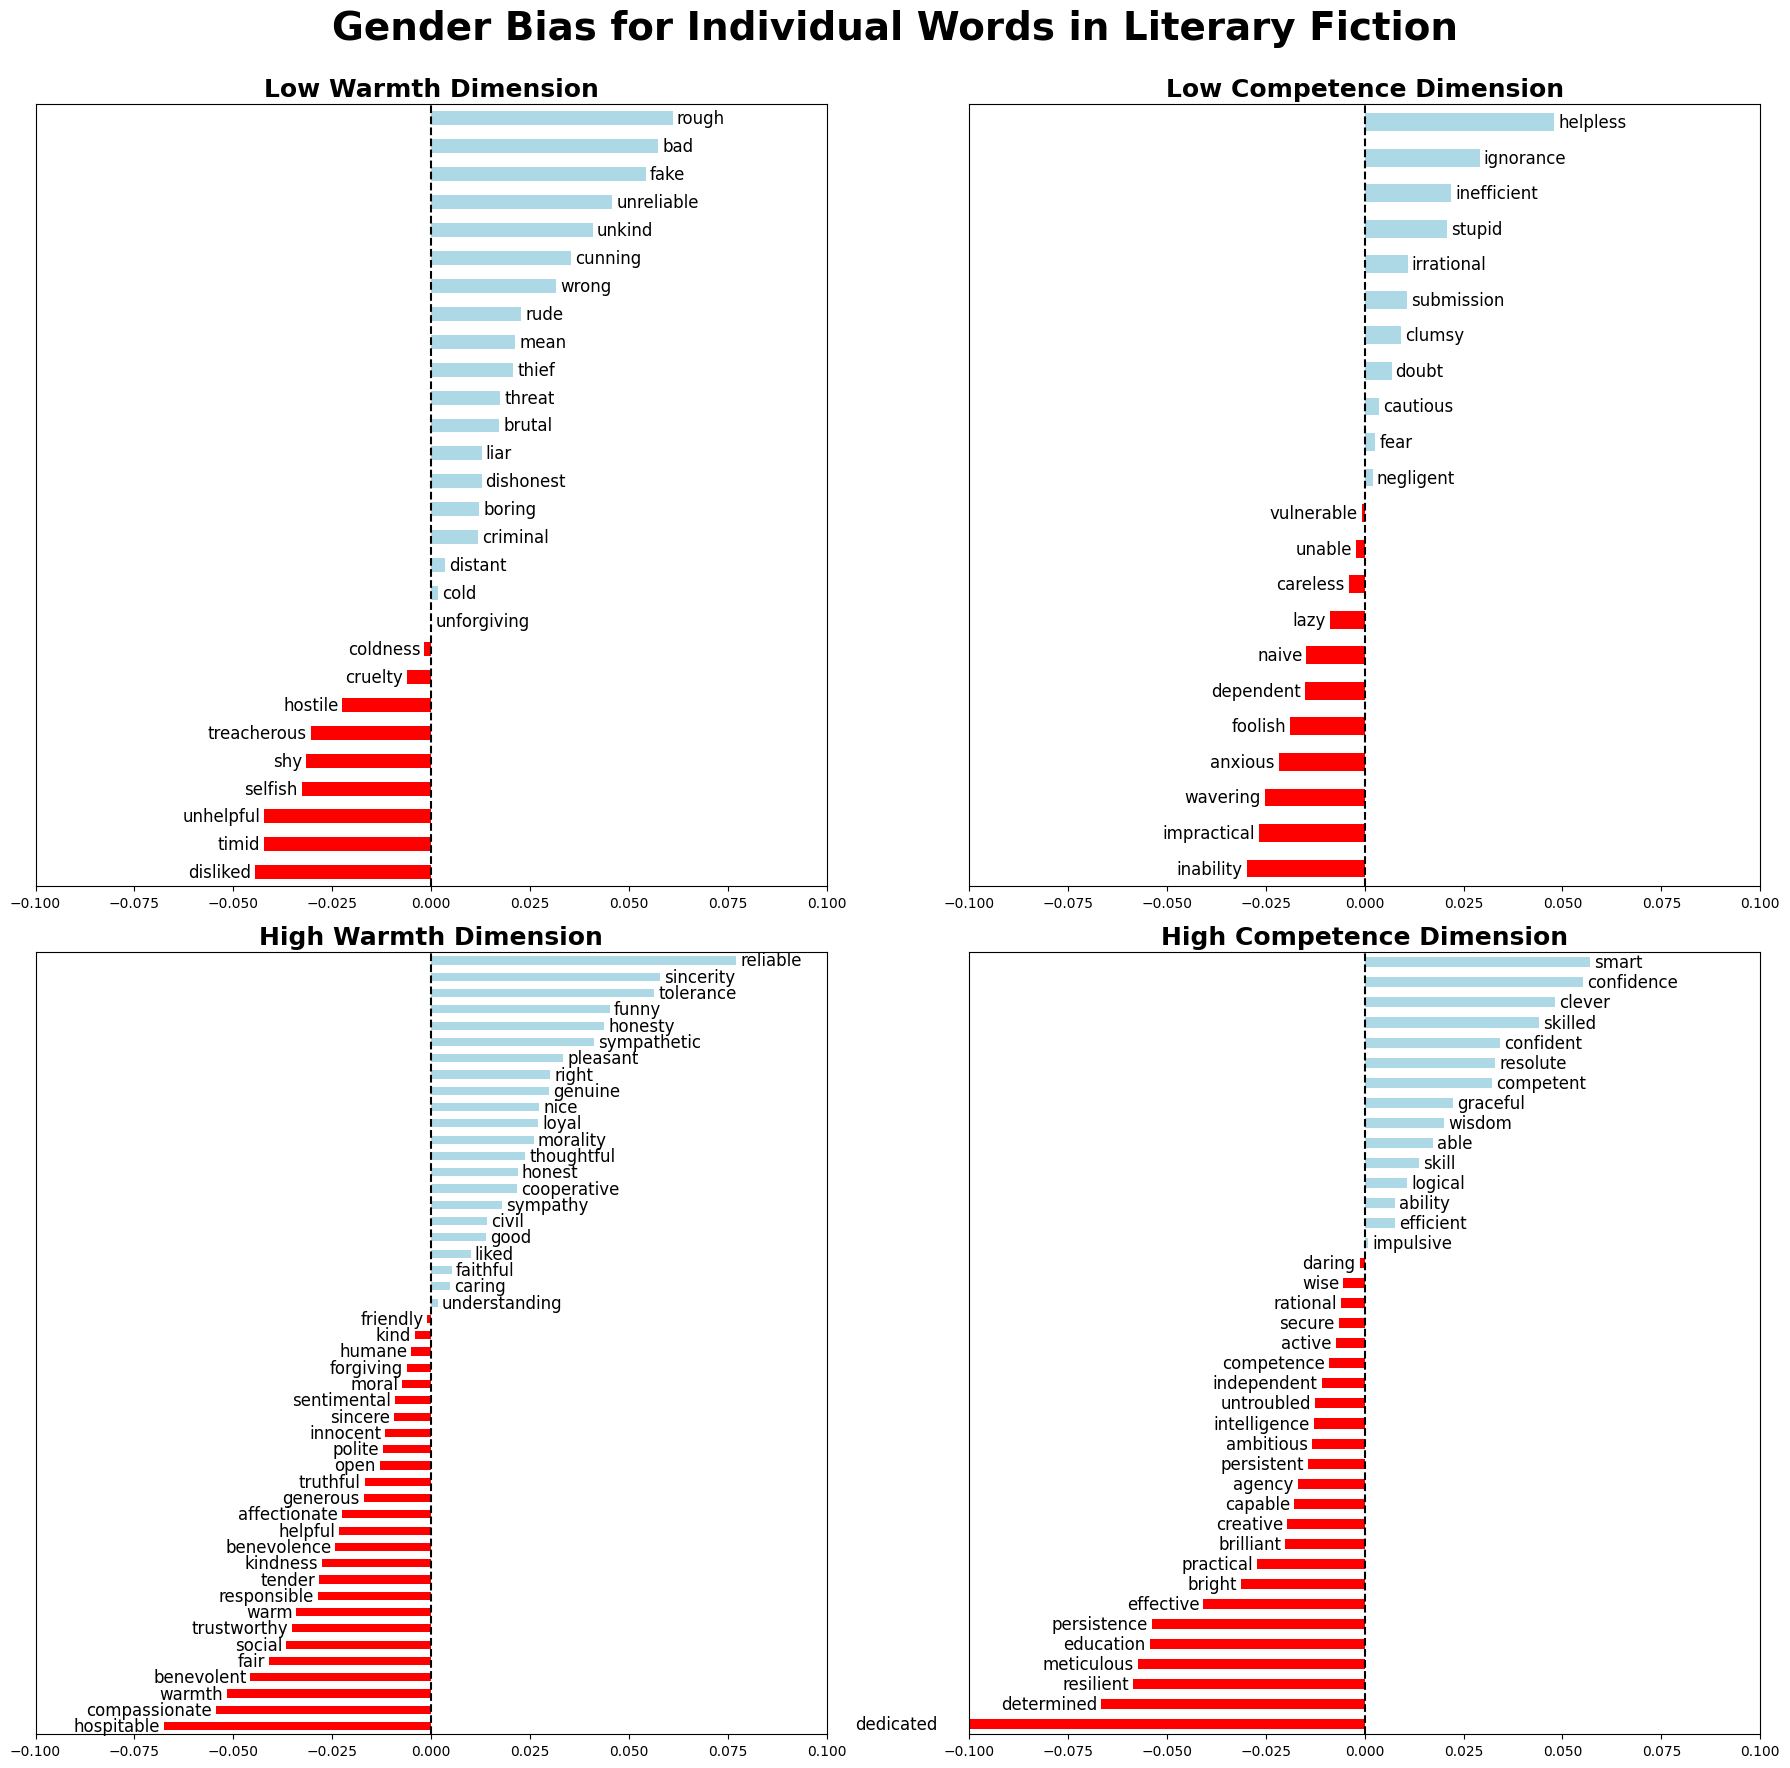

In [27]:
plot_gender_bias_words(gender_bias_df_literary_fiction, "Literary Fiction")

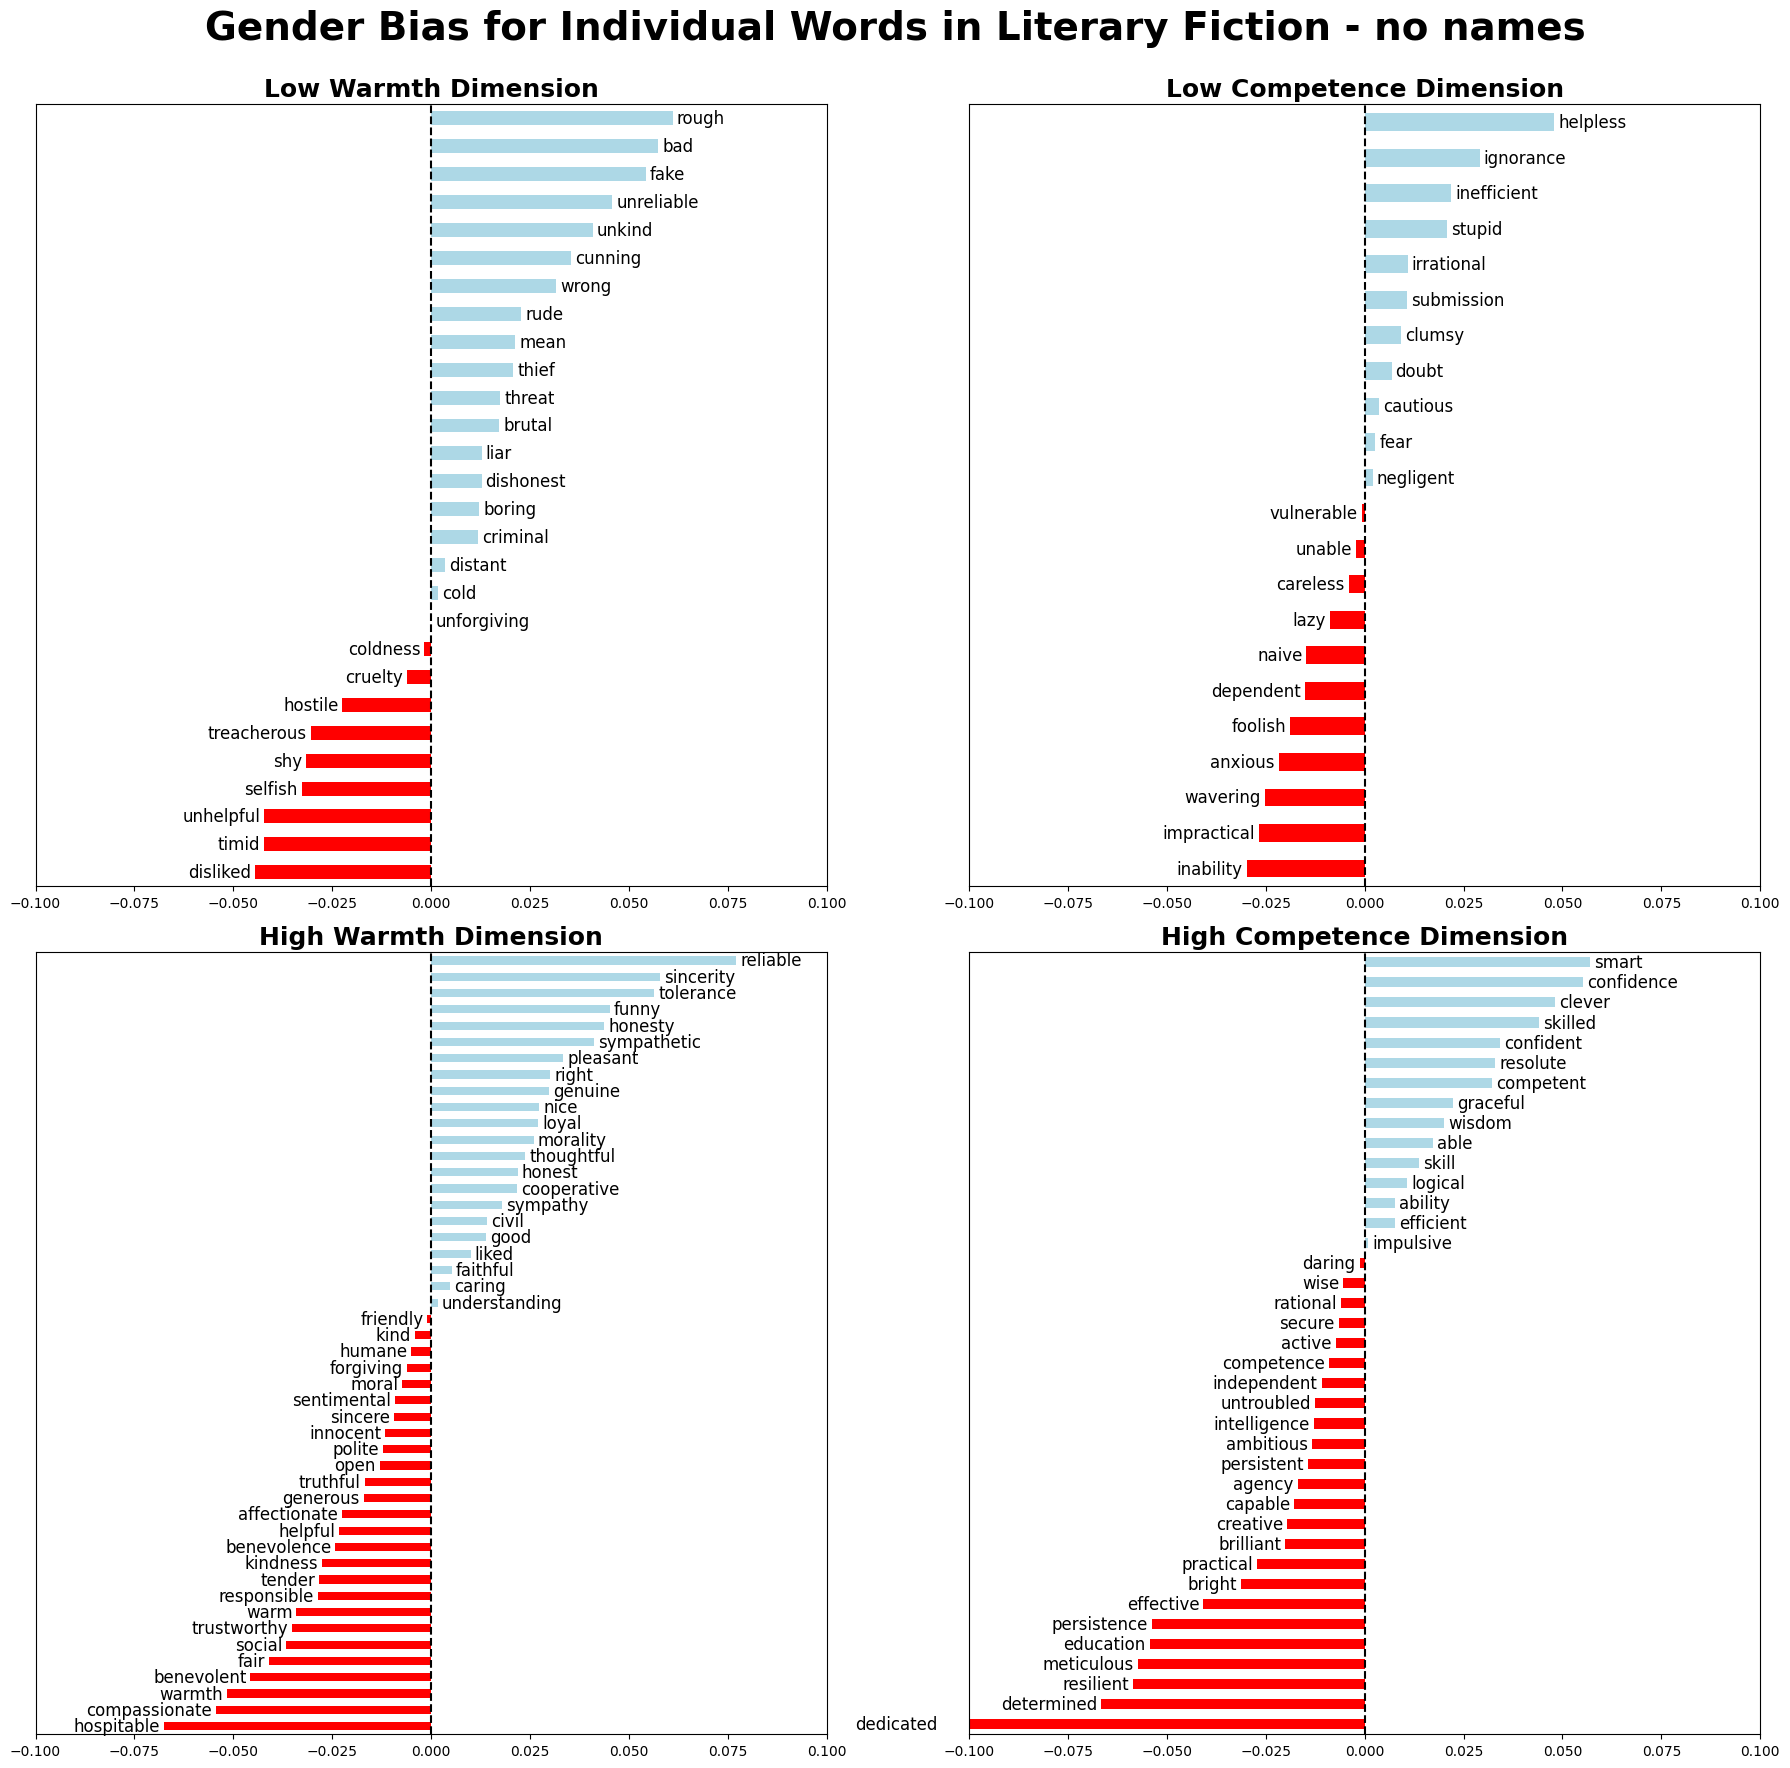

In [28]:
plot_gender_bias_words(gender_bias_df_literary_fiction_no_names, "Literary Fiction - no names")

##### Romance

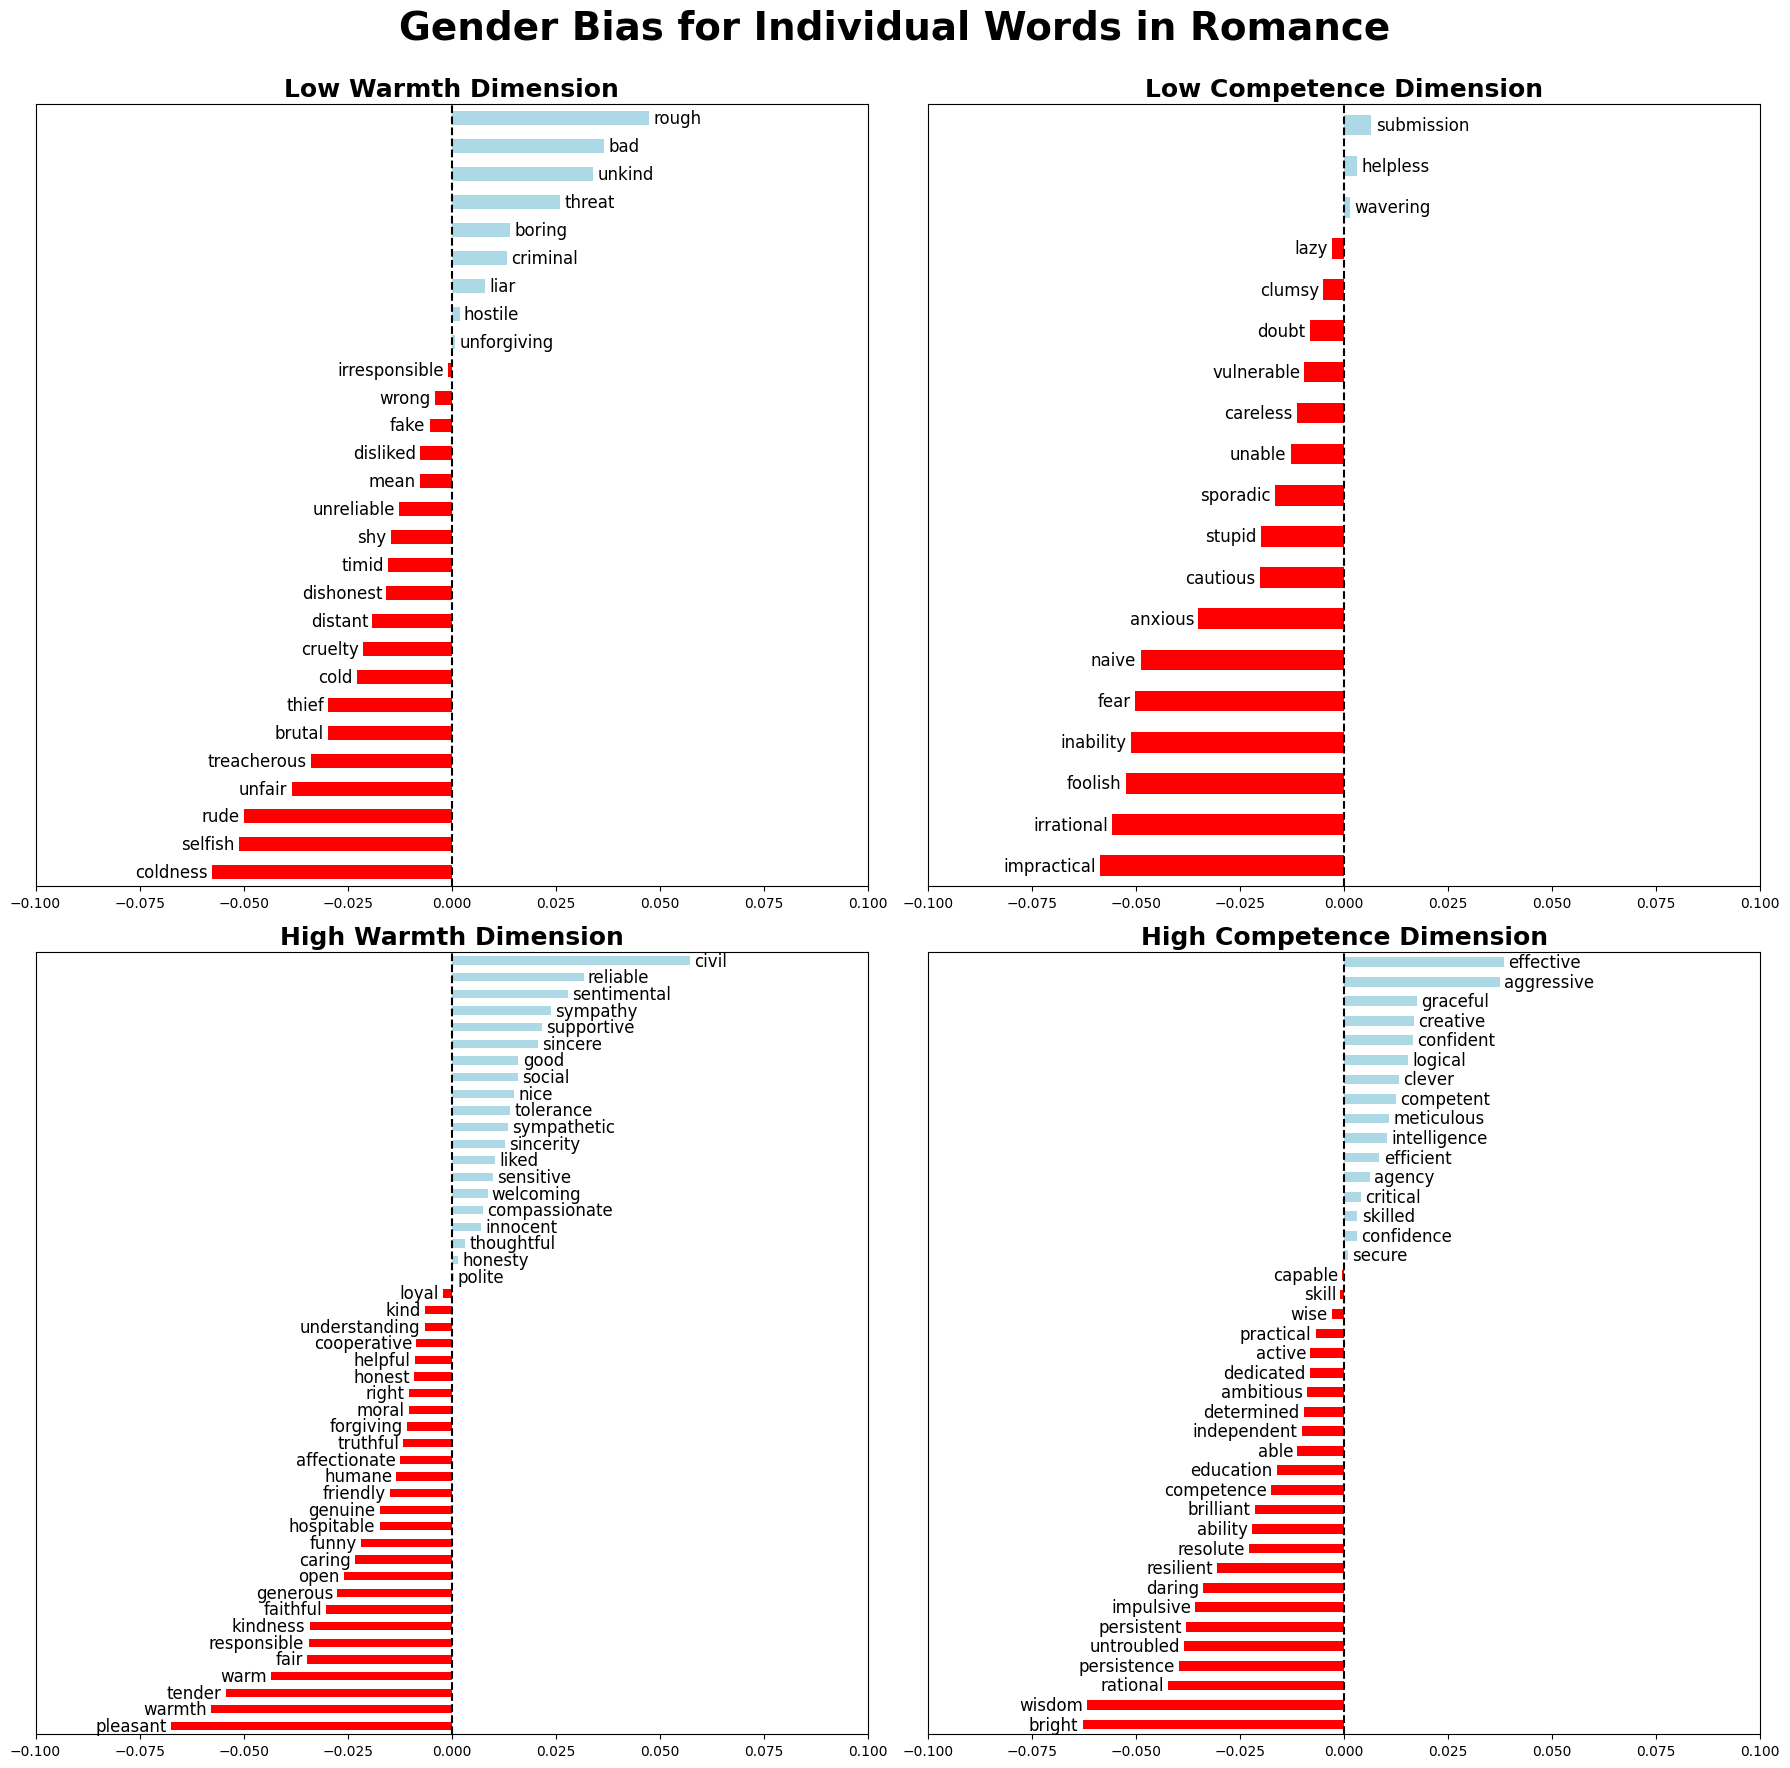

In [29]:
plot_gender_bias_words(gender_bias_df_romance, "Romance")

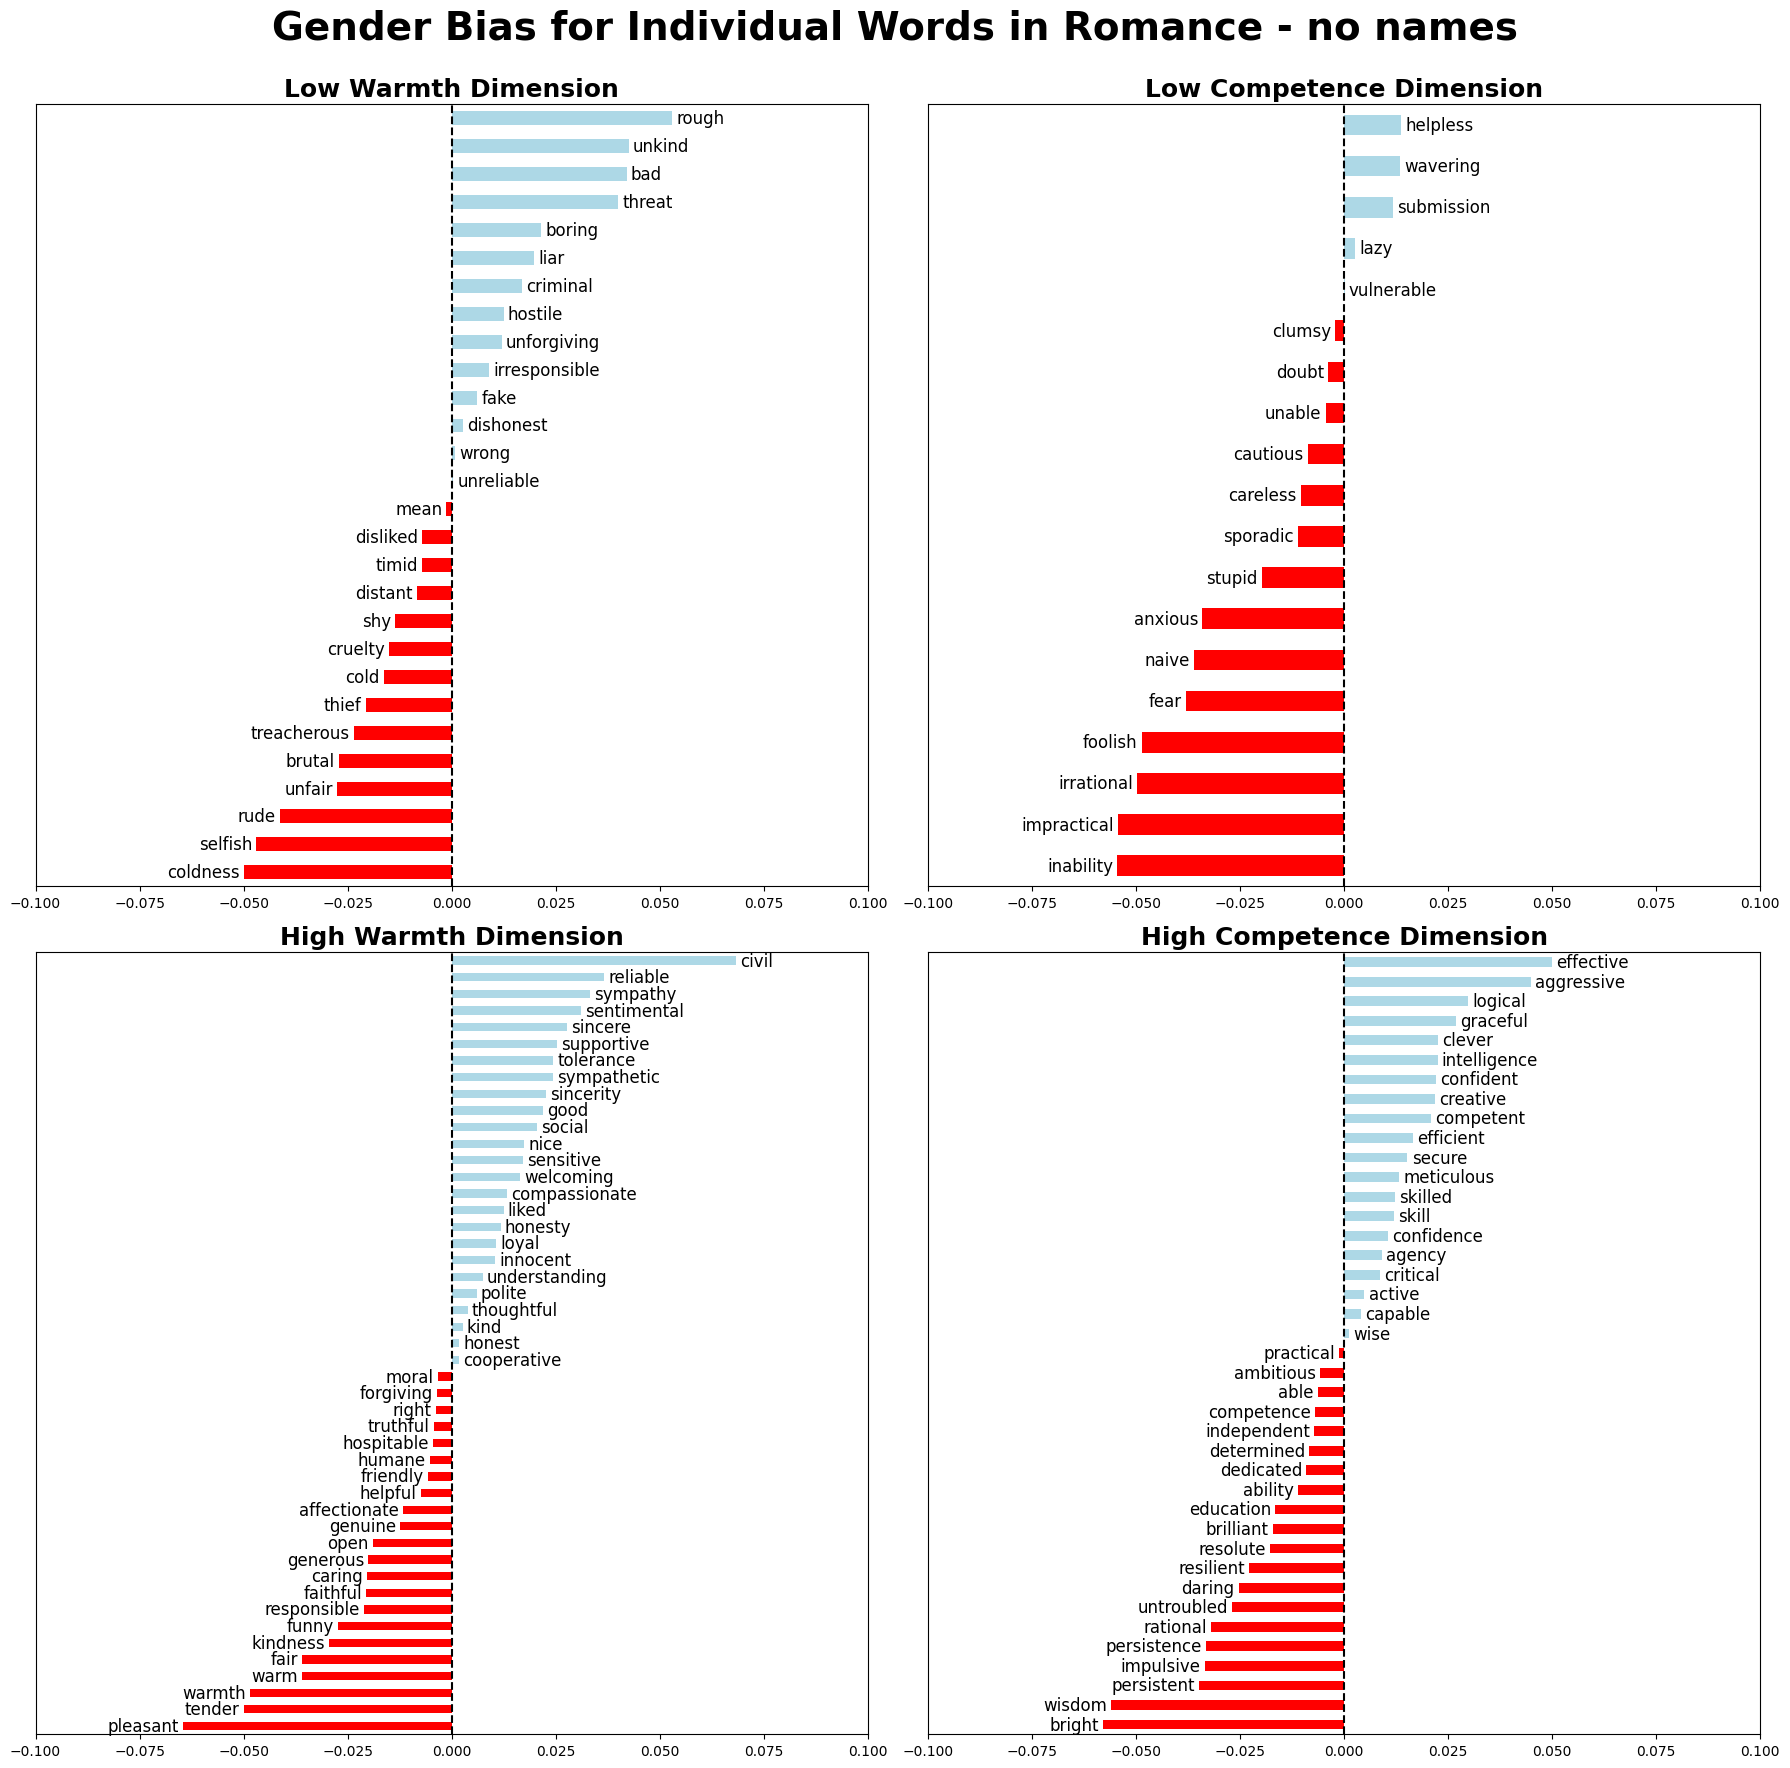

In [30]:
plot_gender_bias_words(gender_bias_df_romance_no_names, "Romance - no names")

##### Sci Fi

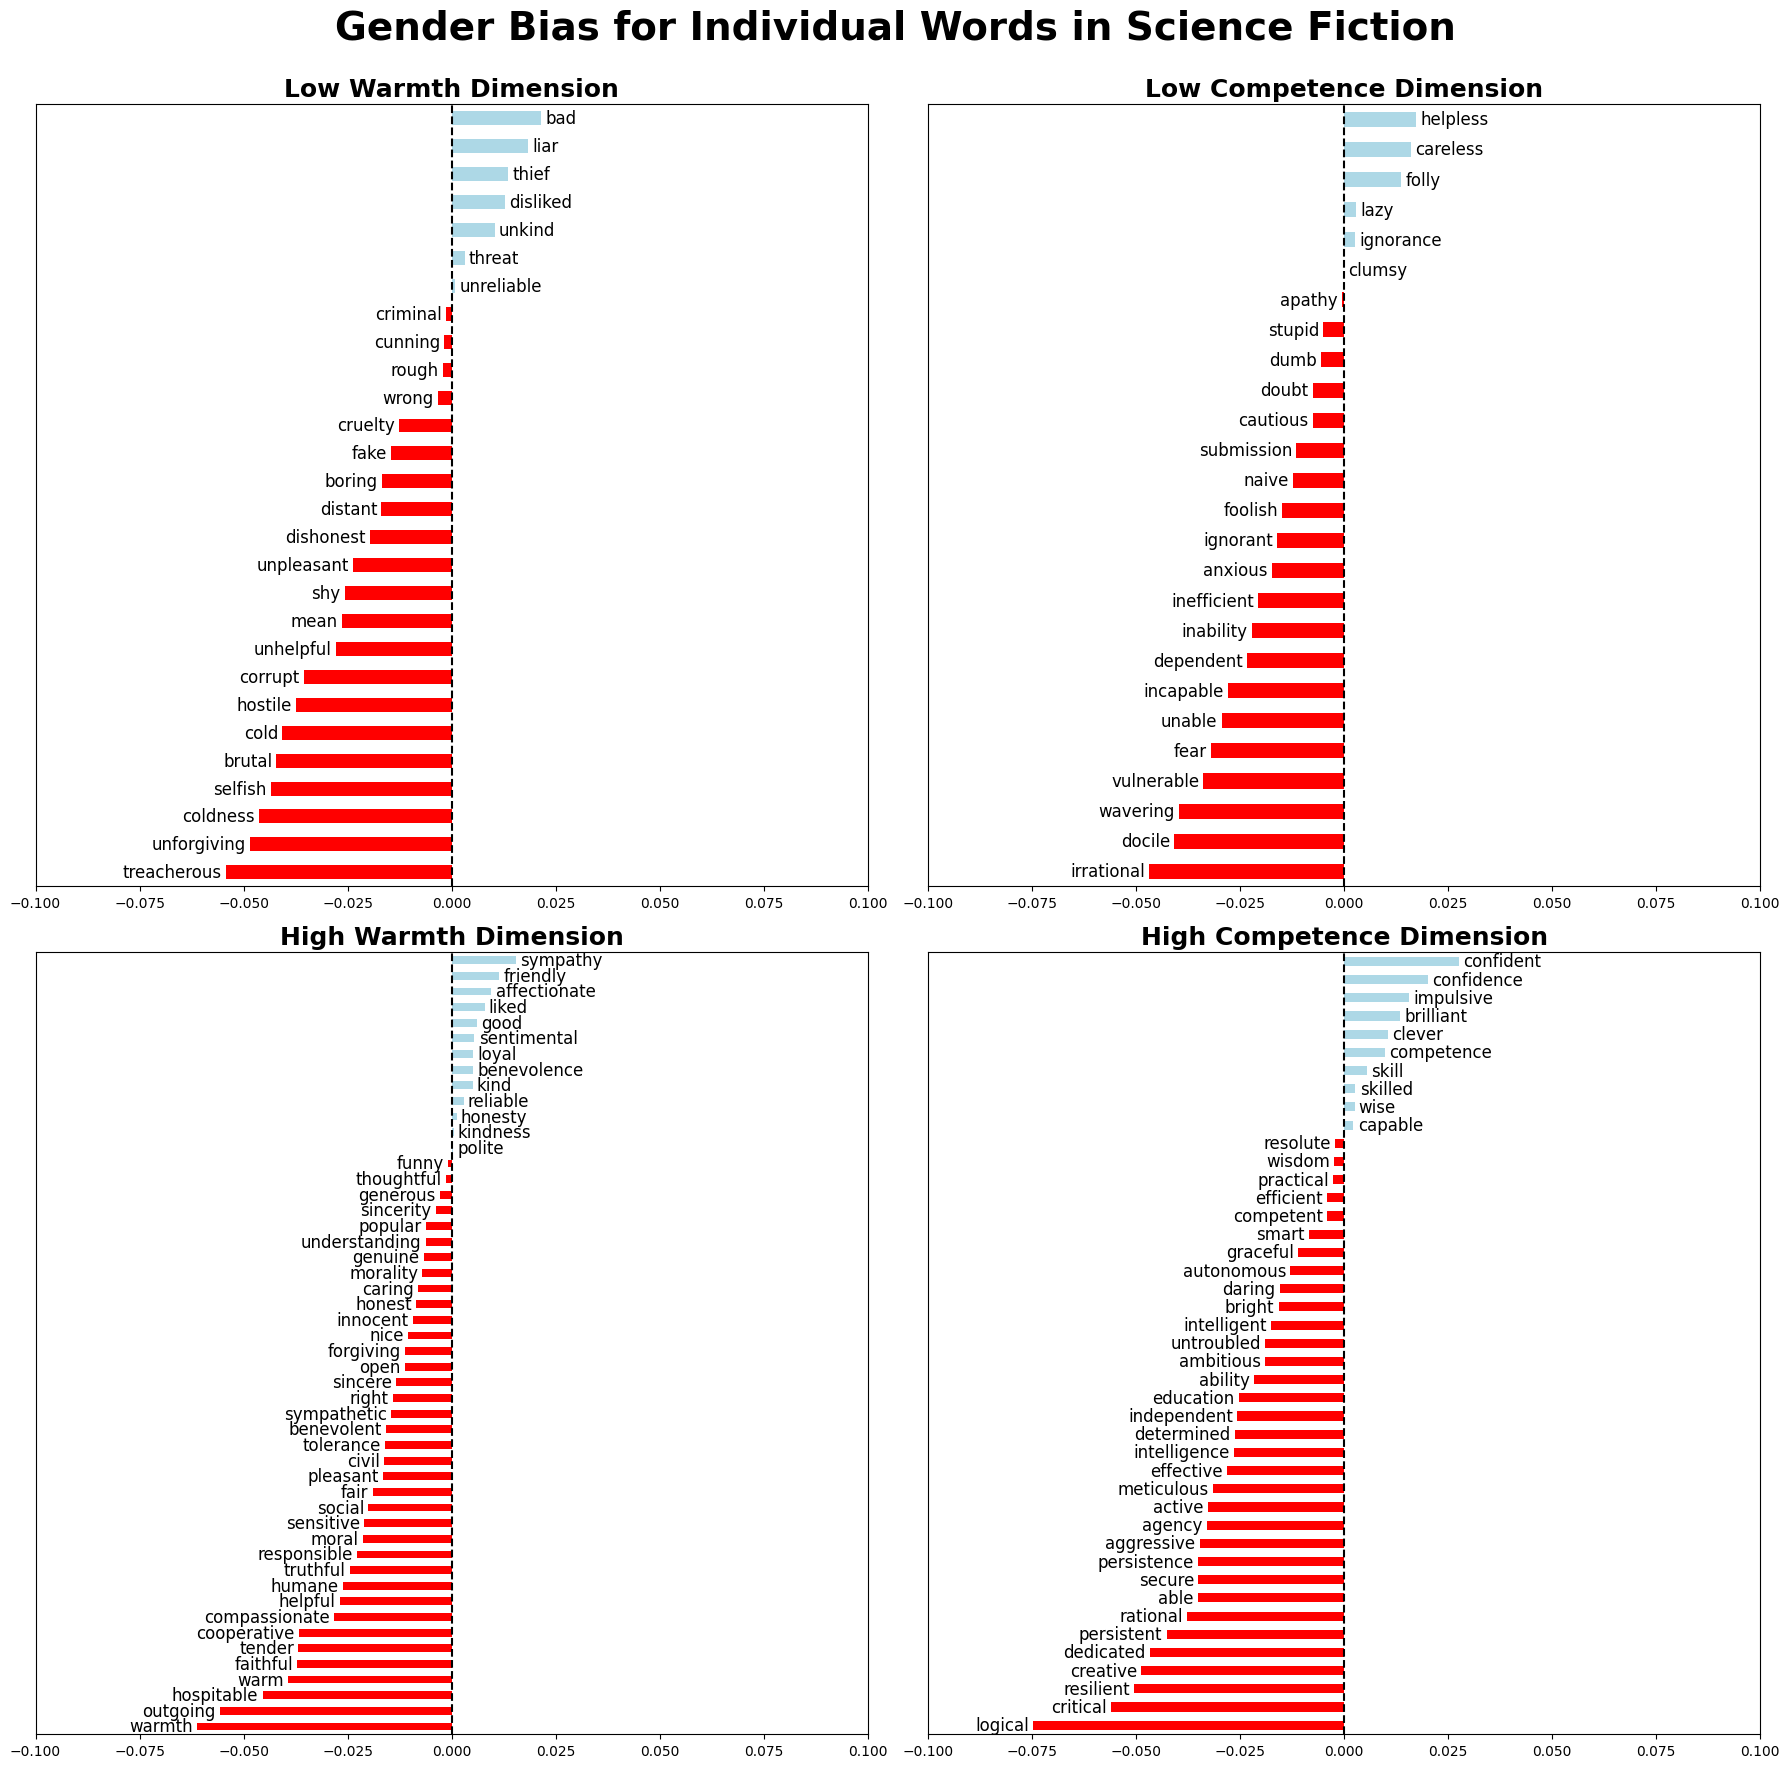

In [31]:
plot_gender_bias_words(gender_bias_df_sci_fi, "Science Fiction")

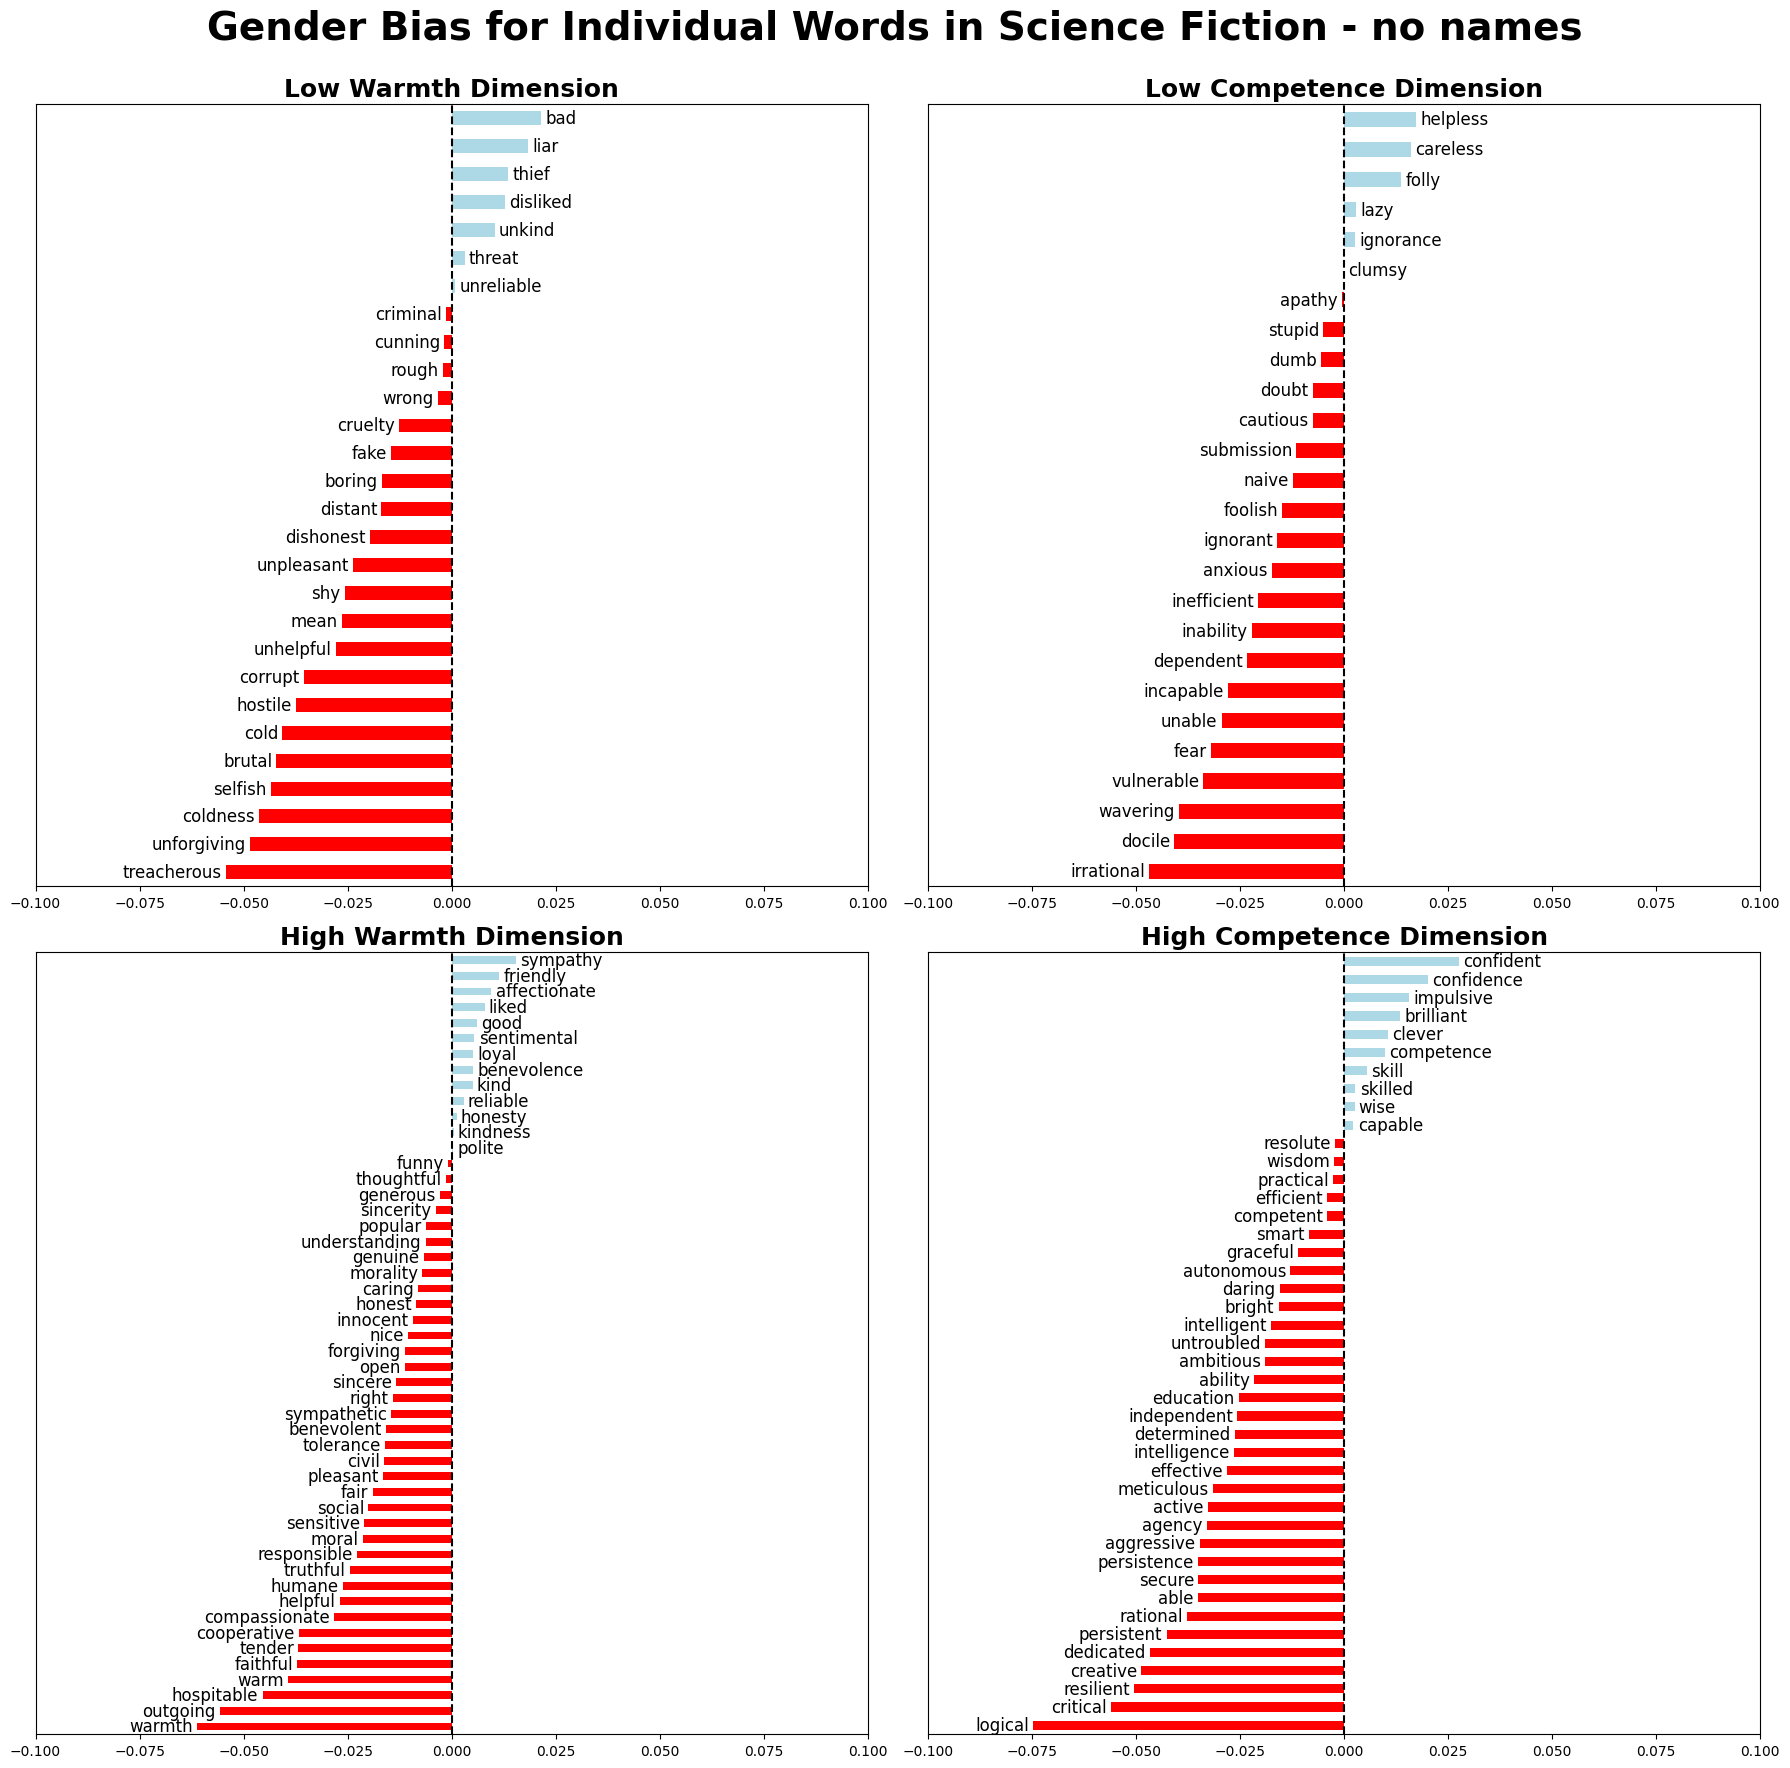

In [32]:
plot_gender_bias_words(gender_bias_df_sci_fi_no_names, "Science Fiction - no names")